In [30]:
import pickle
import numpy as np
import pandas as pd
from time import time
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

In [31]:
with open('Pickles/df_features_train.pickle', 'rb') as f:
    df_train = pickle.load(f)

df_train.head()

,harmonic,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,contrast_chroma_3,contrast_chroma_4,contrast_chroma_5,contrast_chroma_6,contrast_chroma_7,contrast_chroma_8,contrast_chroma_9,contrast_chroma_10,contrast_chroma_11,targets
bass_synthetic_140-059-100,1,-329.939056,123.973106,-35.557831,5.184458,-1.670301,-12.658237,-10.339942,-14.600763,-9.472772,...,0.129883,0.020905,0.017564,0.400633,0.000000,0.011549,0.018656,0.061866,0.868227,0
bass_synthetic_092-073-050,0,-431.613892,39.319218,12.590465,12.088023,5.964242,10.745396,9.005309,7.235996,2.722795,...,0.261954,0.232402,0.220589,0.188489,0.174863,0.184297,0.132321,0.115368,0.121789,0
bass_synthetic_013-081-075,1,-512.969116,8.123688,-6.578756,-5.723709,-0.633847,-2.716123,-3.236486,3.774125,10.099844,...,0.112376,0.132049,0.104429,0.088639,0.076009,0.070041,0.788973,0.059094,0.054781,0
bass_synthetic_113-023-100,0,-263.997437,126.403450,-1.320596,58.091305,50.569607,3.494572,25.643167,36.695126,21.652494,...,0.021547,0.007723,0.001906,0.223943,0.000000,0.000000,0.000000,0.006329,0.911447,0
bass_synthetic_079-088-050,0,-486.779663,8.236533,-3.788402,-2.884458,3.188778,8.633821,6.403360,-2.633486,-8.461335,...,0.165583,0.735046,0.138624,0.105541,0.081290,0.065969,0.069501,0.061035,0.103024,0


In [32]:
df_train.shape

(50000, 167)

In [33]:
with open('Pickles/df_features_test.pickle', 'rb') as f:
    df_test = pickle.load(f)

df_test.head()

,harmonic,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,contrast_chroma_3,contrast_chroma_4,contrast_chroma_5,contrast_chroma_6,contrast_chroma_7,contrast_chroma_8,contrast_chroma_9,contrast_chroma_10,contrast_chroma_11,targets
bass_synthetic_068-049-025,1,-522.865784,46.664146,34.379799,24.787592,17.420424,10.198802,4.609534,1.380598,-1.023342,...,0.034056,0.035498,0.025267,0.019353,0.038954,0.092328,0.087519,0.061090,0.091117,0
keyboard_electronic_001-021-127,0,-444.647125,193.894592,27.295811,-3.687870,6.295289,8.091360,10.286986,6.085114,2.499446,...,0.392218,0.563529,0.143236,0.164834,0.211634,0.353580,0.422365,0.019230,0.009007,4
guitar_acoustic_010-066-100,0,-439.374725,59.548592,2.893683,-12.038996,-12.553400,-11.452487,-12.534291,-20.458334,-19.255125,...,0.072573,0.091863,0.090990,0.840737,0.093613,0.048391,0.030883,0.015003,0.009667,3
reed_acoustic_037-068-127,1,-374.560974,70.889236,-41.184624,-20.965775,-50.554077,-16.927151,-28.767248,-18.298323,-15.653652,...,0.366166,0.036109,0.006731,0.023056,0.020713,0.885966,0.061736,0.016221,0.002263,7
flute_acoustic_002-077-100,1,-365.428162,13.425872,-43.518299,20.321766,-29.725790,-21.518469,-17.812229,-10.225934,8.543967,...,0.037789,0.052419,0.910790,0.022027,0.030132,0.009579,0.028886,0.048302,0.016970,2


In [34]:
#get training and testing data
X_train = df_train.drop(labels=['targets'], axis=1)
y_train = df_train['targets']

X_test = df_test.drop(labels=['targets'], axis=1)
y_test = df_test['targets']

# Naive Bayes

In [35]:
#instantiate the classifier
clf_NB = GaussianNB()

#fit to training data
clf_NB.fit(X_train, y_train)

GaussianNB()

In [36]:
y_pred_NB = clf_NB.predict(X_test)

In [37]:
accuracy_NB = np.mean(y_pred_NB == y_test)
print("The accuracy of Naive Bayes is {0:.2%}".format(accuracy_NB))

The accuracy of Naive Bayes is 12.94%


In [38]:
#Naive Byaes Output in User Understandable format
instruments = []

for i in y_pred_NB:
    if i == 0:
        instruments.append("Bass")
    elif i == 1:
        instruments.append("Brass")
    elif i == 2:
        instruments.append("Flute")
    elif i == 3:
        instruments.append("Guitar")
    elif i == 4:
        instruments.append("Piano")
    elif i == 5:
        instruments.append("Mallet")
    elif i == 6:
        instruments.append("Organ")
    elif i == 7:
        instruments.append("Reed")
    elif i == 8:
        instruments.append("Strings")
    elif i == 9:
        instruments.append("Vocal")
    else:
        instruments.append("Unknown")
    


instruments

['Strings',
 'Strings',
 'Brass',
 'Brass',
 'Flute',
 'Strings',
 'Unknown',
 'Mallet',
 'Brass',
 'Strings',
 'Strings',
 'Strings',
 'Piano',
 'Strings',
 'Strings',
 'Brass',
 'Strings',
 'Strings',
 'Brass',
 'Flute',
 'Brass',
 'Unknown',
 'Brass',
 'Strings',
 'Strings',
 'Strings',
 'Strings',
 'Strings',
 'Piano',
 'Strings',
 'Strings',
 'Piano',
 'Strings',
 'Flute',
 'Brass',
 'Brass',
 'Flute',
 'Piano',
 'Strings',
 'Strings',
 'Strings',
 'Brass',
 'Strings',
 'Strings',
 'Guitar',
 'Strings',
 'Brass',
 'Strings',
 'Flute',
 'Strings',
 'Strings',
 'Strings',
 'Piano',
 'Strings',
 'Strings',
 'Brass',
 'Brass',
 'Strings',
 'Strings',
 'Unknown',
 'Strings',
 'Piano',
 'Flute',
 'Strings',
 'Brass',
 'Piano',
 'Strings',
 'Brass',
 'Strings',
 'Piano',
 'Piano',
 'Brass',
 'Strings',
 'Piano',
 'Guitar',
 'Reed',
 'Strings',
 'Strings',
 'Strings',
 'Brass',
 'Piano',
 'Piano',
 'Strings',
 'Piano',
 'Strings',
 'Mallet',
 'Flute',
 'Reed',
 'Piano',
 'Strings',
 'Pian

In [39]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots(figsize=(10,10))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    #fig.tight_layout()
    return ax

In [40]:
class_names=np.array(['bass', 'brass', 'flute', 'guitar', 
             'Piano', 'mallet', 'organ', 'reed', 
             'string', 'synth_lead', 'vocal'])

Normalized confusion matrix
[[0.00474496 0.05931198 0.         0.00474496 0.25622776 0.04982206
  0.         0.02135231 0.56702254 0.03677343]
 [0.01858736 0.36802974 0.00371747 0.01486989 0.05204461 0.19330855
  0.00371747 0.00743494 0.28996283 0.04832714]
 [0.00555556 0.3        0.10555556 0.00555556 0.20555556 0.05
  0.02222222 0.07222222 0.23333333 0.        ]
 [0.00306748 0.22546012 0.0107362  0.00920245 0.08742331 0.01993865
  0.00460123 0.02147239 0.61809816 0.        ]
 [0.         0.22584856 0.         0.00522193 0.03785901 0.01827676
  0.         0.00130548 0.71148825 0.        ]
 [0.         0.10891089 0.         0.         0.04455446 0.
  0.0049505  0.         0.82178218 0.01980198]
 [0.0059761  0.41633466 0.06972112 0.01792829 0.13944223 0.00996016
  0.10956175 0.03386454 0.16733068 0.02988048]
 [0.00851064 0.50638298 0.0212766  0.00425532 0.00425532 0.
  0.00425532 0.00851064 0.44255319 0.        ]
 [0.         0.12418301 0.         0.00326797 0.01633987 0.00653595
  0.00

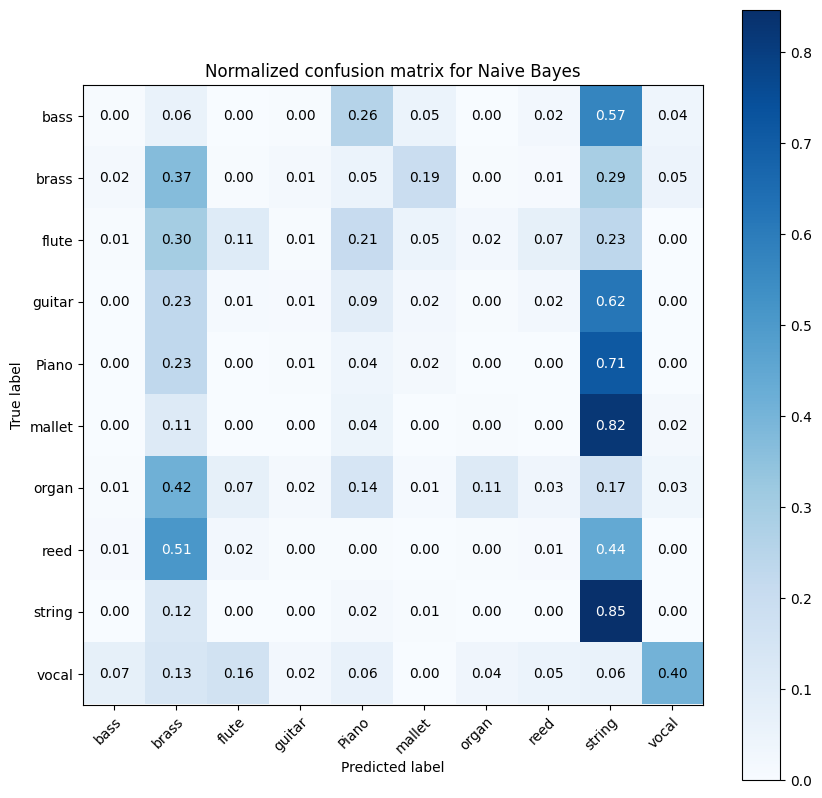

In [41]:
plot_confusion_matrix(y_test, y_pred_NB, classes=class_names, normalize=True,
                      title='Normalized confusion matrix for Naive Bayes')
plt.savefig('ConfusionMatrix/NB_normalized.png')

# Random Forests

In [42]:
#instantiate the random forest
clf_Rf =RandomForestClassifier(n_estimators=20, max_depth=50, warm_start=True)

In [43]:
clf_Rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=50, n_estimators=20, warm_start=True)

In [44]:
y_pred_RF = clf_Rf.predict(X_test)

In [45]:
accuracy_RF = np.mean(y_pred_RF == y_test)
print("The accuracy of Random Forest is {0:.2%}".format(accuracy_RF))

The accuracy of Random Forest is 57.06%


In [46]:
#NRandom Forest Output in User Understandable format
instruments.clear()

for i in y_pred_RF:
    if i == 0:
        instruments.append("Bass")
    elif i == 1:
        instruments.append("Brass")
    elif i == 2:
        instruments.append("Flute")
    elif i == 3:
        instruments.append("Guitar")
    elif i == 4:
        instruments.append("Piano")
    elif i == 5:
        instruments.append("Mallet")
    elif i == 6:
        instruments.append("Organ")
    elif i == 7:
        instruments.append("Reed")
    elif i == 8:
        instruments.append("Strings")
    elif i == 9:
        instruments.append("Vocal")
    else:
        instruments.append("Unknown")
    


instruments

['Bass',
 'Piano',
 'Piano',
 'Brass',
 'Flute',
 'Strings',
 'Bass',
 'Bass',
 'Guitar',
 'Strings',
 'Bass',
 'Piano',
 'Bass',
 'Piano',
 'Bass',
 'Piano',
 'Flute',
 'Guitar',
 'Organ',
 'Organ',
 'Organ',
 'Bass',
 'Mallet',
 'Guitar',
 'Guitar',
 'Piano',
 'Piano',
 'Guitar',
 'Mallet',
 'Bass',
 'Guitar',
 'Bass',
 'Organ',
 'Flute',
 'Reed',
 'Organ',
 'Organ',
 'Mallet',
 'Reed',
 'Guitar',
 'Guitar',
 'Organ',
 'Bass',
 'Bass',
 'Bass',
 'Piano',
 'Reed',
 'Bass',
 'Flute',
 'Piano',
 'Guitar',
 'Mallet',
 'Mallet',
 'Guitar',
 'Guitar',
 'Piano',
 'Piano',
 'Organ',
 'Piano',
 'Bass',
 'Organ',
 'Bass',
 'Flute',
 'Piano',
 'Guitar',
 'Guitar',
 'Guitar',
 'Organ',
 'Guitar',
 'Mallet',
 'Bass',
 'Guitar',
 'Bass',
 'Bass',
 'Piano',
 'Organ',
 'Piano',
 'Guitar',
 'Piano',
 'Mallet',
 'Bass',
 'Strings',
 'Brass',
 'Bass',
 'Bass',
 'Piano',
 'Flute',
 'Bass',
 'Unknown',
 'Brass',
 'Bass',
 'Reed',
 'Guitar',
 'Organ',
 'Strings',
 'Guitar',
 'Bass',
 'Piano',
 'Bass',
 'B

Normalized confusion matrix
[[0.59193357 0.00237248 0.         0.07947805 0.11150652 0.1767497
  0.02016607 0.01067616 0.00118624 0.0059312 ]
 [0.18587361 0.68401487 0.03345725 0.01486989 0.02230483 0.00371747
  0.         0.02230483 0.01486989 0.01858736]
 [0.03888889 0.00555556 0.7        0.00555556 0.03333333 0.03888889
  0.06111111 0.06111111 0.         0.05555556]
 [0.19631902 0.00460123 0.00920245 0.50766871 0.2101227  0.05368098
  0.01226994 0.00306748 0.00306748 0.        ]
 [0.18407311 0.01958225 0.01044386 0.21409922 0.49869452 0.04569191
  0.01044386 0.00261097 0.00913838 0.00522193]
 [0.14356436 0.01485149 0.0049505  0.17326733 0.15841584 0.5049505
  0.         0.         0.         0.        ]
 [0.10557769 0.01394422 0.03984064 0.00199203 0.03386454 0.03585657
  0.57370518 0.06175299 0.02390438 0.10956175]
 [0.01702128 0.27659574 0.07234043 0.09787234 0.02553191 0.
  0.00425532 0.40425532 0.09361702 0.00851064]
 [0.09803922 0.01960784 0.00326797 0.02941176 0.02941176 0.049

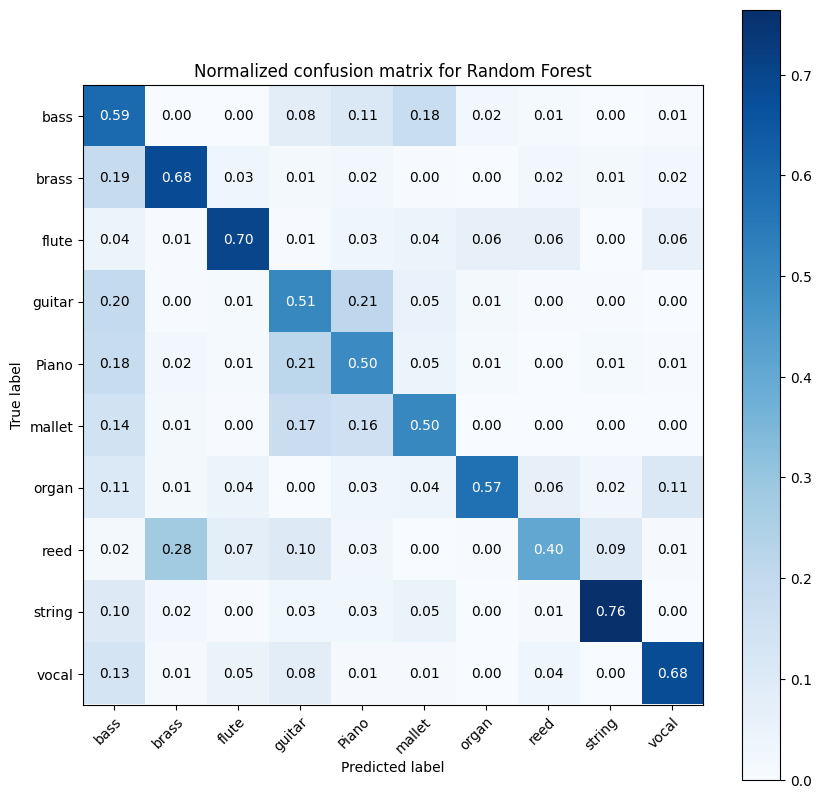

In [47]:
plot_confusion_matrix(y_test, y_pred_RF, classes=class_names, normalize=True,
                      title='Normalized confusion matrix for Random Forest')
plt.savefig('ConfusionMatrix/RF_Normalized.png')

## Grid Search

In [48]:
# Utility function to report best scores
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

In [49]:
param_dist = {"n_estimators" : [20, 40, 60, 80],
              "max_depth": [10, 20, 30, 40],
              "max_features": sp_randint(1, 11),
              "min_samples_split": sp_randint(2, 11),
              "bootstrap": [True, False],
              "criterion": ["gini", "entropy"]}

In [50]:
#instantiate a new random forest
clf_RF_CV=RandomForestClassifier()

#set number of iterations
n_iter_search = 20
#creat the random search class
random_search_RF = RandomizedSearchCV(clf_RF_CV, param_distributions=param_dist,
                                      n_iter=n_iter_search, cv=5)
#
random_search_RF.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, 40],
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x147f97910>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x147ff6590>,
                                        'n_estimators': [20, 40, 60, 80]})

In [51]:
y_pred_RF_random = random_search_RF.predict(X_test)
accuracy_RF_random = np.mean(y_pred_RF_random == y_test)
print("The accuracy of Random Forest is {0:.2%}".format(accuracy_RF_random))

The accuracy of Random Forest is 60.57%


Normalized confusion matrix
[[0.58956109 0.         0.         0.0747331  0.11862396 0.18979834
  0.01423488 0.01067616 0.00237248 0.        ]
 [0.18215613 0.66914498 0.0260223  0.05204461 0.00371747 0.
  0.         0.01858736 0.         0.04832714]
 [0.00555556 0.         0.75555556 0.         0.01111111 0.02222222
  0.13888889 0.01666667 0.         0.05      ]
 [0.15797546 0.00153374 0.00460123 0.52760736 0.22852761 0.06595092
  0.01380368 0.         0.         0.        ]
 [0.15535248 0.01305483 0.00391645 0.20365535 0.55744125 0.04438642
  0.01044386 0.         0.00652742 0.00522193]
 [0.08415842 0.00990099 0.         0.06930693 0.21782178 0.61386139
  0.         0.0049505  0.         0.        ]
 [0.0936255  0.0059761  0.04581673 0.         0.02788845 0.04581673
  0.58366534 0.05976096 0.03784861 0.09960159]
 [0.         0.30638298 0.06808511 0.05957447 0.         0.00425532
  0.         0.42978723 0.11914894 0.01276596]
 [0.02614379 0.00326797 0.         0.01960784 0.         0.0

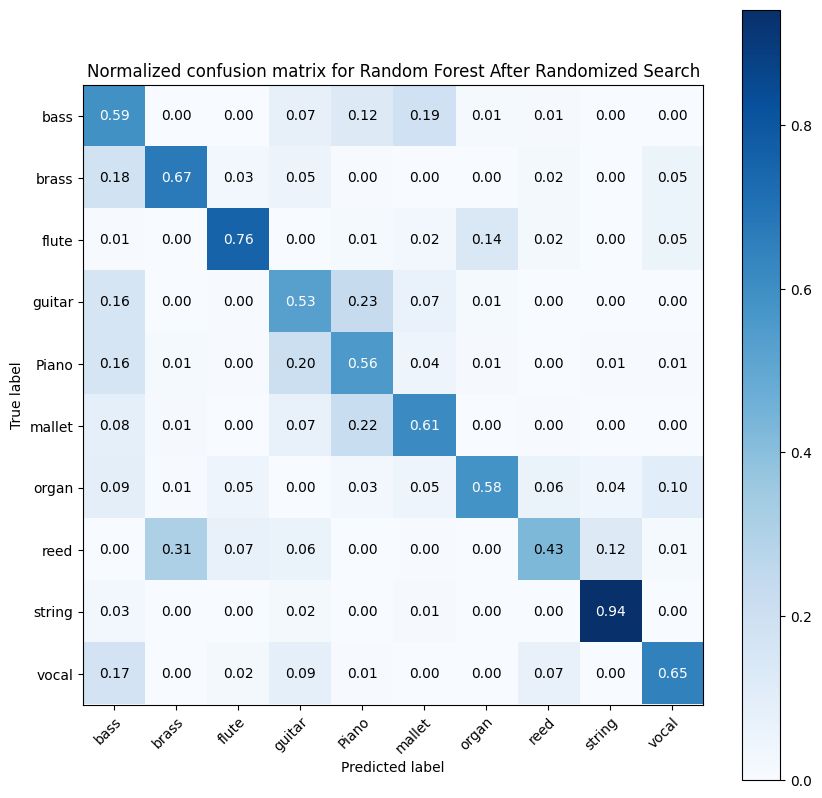

In [52]:
plot_confusion_matrix(y_test, y_pred_RF_random, classes=class_names, normalize=True,
                      title='Normalized confusion matrix for Random Forest After Randomized Search')
plt.savefig('ConfusionMatrix/RF_Normalized_RandomSearch.png')

In [53]:
random_search_RF.best_estimator_

RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=20,
                       max_features=10, min_samples_split=4, n_estimators=80)

In [56]:
# pickle the trained model
with open("Models/random_search_RF.pickle", mode='wb') as file:
    pickle.dump(random_search_RF, file)

# SVM

In [57]:
#instantiate the sclaer
scaler = MinMaxScaler()

In [58]:
#scale the feature space
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

In [59]:
#instatiate the  classifier
clf_svm = SVC(C=0.1)

In [60]:
clf_svm.fit(X_train_scale, y_train)

SVC(C=0.1)

In [61]:
y_pred_svm = clf_svm.predict(X_test)
accuracy_svm = np.mean(y_pred_svm == y_test)
print("The accuracy of SVMs is {0:.2%}".format(accuracy_svm))

/Users/ritanshudeshmukh/miniforge3/lib/python3.10/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


The accuracy of SVMs is 3.44%


In [62]:
#display non normalized confusion matrix
confusion_matrix(y_test, y_pred_svm)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0, 843],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 269],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 180],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 652],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 766],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 202],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 502],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 235],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 306],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 141]])

Normalized confusion matrix
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


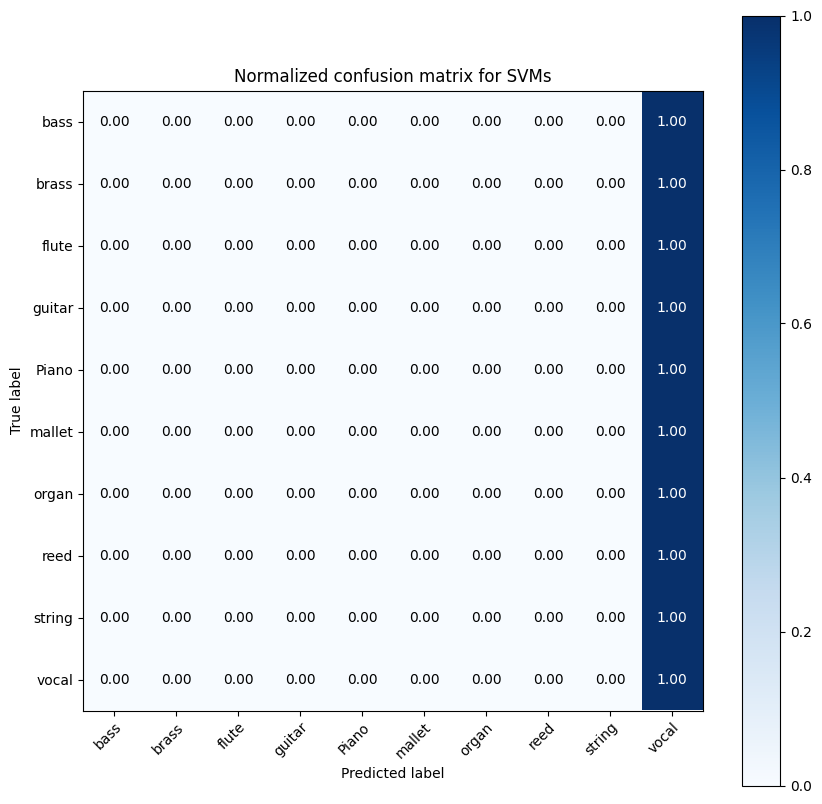

In [63]:
plot_confusion_matrix(y_test, y_pred_svm, classes=class_names, normalize=True,
                      title='Normalized confusion matrix for SVMs')
plt.savefig('ConfusionMatrix/SVM_Normalized.png')